Dataset shape: (20640, 8)

5 first sample: 
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

 Target (housing price in $100,000): [4.526 3.585 3.521 3.413 3.422]


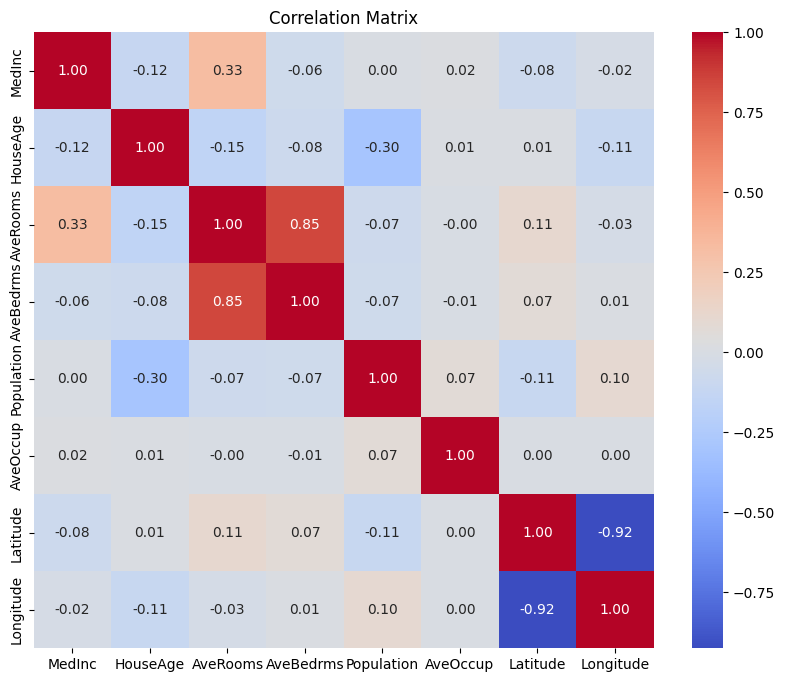


Correlation with target variable:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
dtype: float64


In [2]:
# Linear Regression

# Load & Data Exploration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dataset shape:", X.shape)
print("\n5 first sample: ")
print(X.head())
print("\n Target (housing price in $100,000):",y[:5])

#descriptive statistics
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Correlation with target variable
corr_with_target = X.corrwith(pd.Series(y))
print("\nCorrelation with target variable:")
print(corr_with_target.sort_values(ascending=False)) #ascending false to show the most correlated features at the top to low


Linear Regression Results:

Training Set Evaluation:
Mean Squared Error: 0.5237
Mean Absolute Error: 0.5297
R^2 Score: 0.6076

Validation Set Evaluation:
Mean Squared Error: 0.5158
Mean Absolute Error: 0.5308
R^2 Score: 0.6144

Test Set Evaluation:
Mean Squared Error: 0.5371
Mean Absolute Error: 0.5354
R^2 Score: 0.5901

Coefficients Model:
      Feature  Coefficient
3   AveBedrms     0.653353
0      MedInc     0.442491
1    HouseAge     0.009291
4  Population    -0.000004
5    AveOccup    -0.003962
2    AveRooms    -0.114989
6    Latitude    -0.416708
7   Longitude    -0.429808


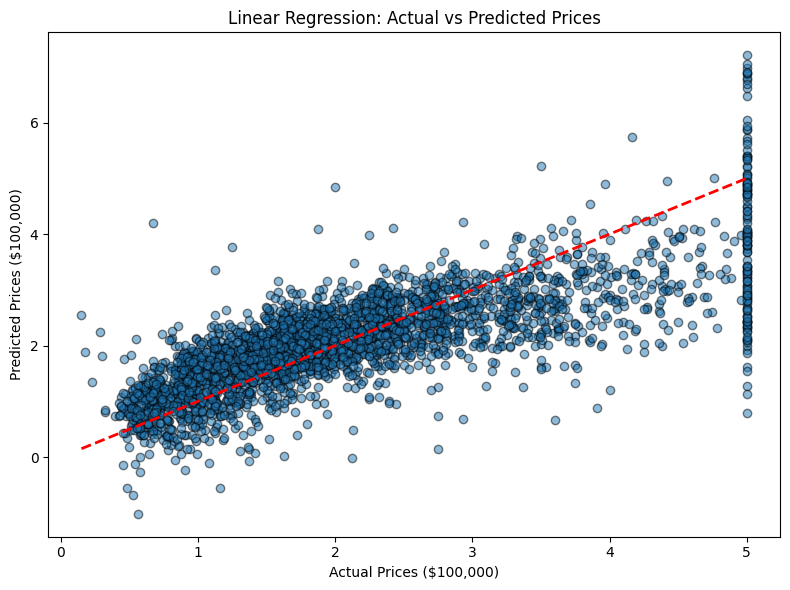

In [10]:
#Training & Evaluation
# Split data (70% train, 15% validation, 15% test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42) # 0.1765 * 0.85 ≈ 0.15

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Prediction
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

# Evaluation
def evaluate_regression(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    return mse, mae, r2

print("Linear Regression Results:")
evaluate_regression(y_train, y_train_pred, "Training Set")
evaluate_regression(y_val, y_val_pred, "Validation Set")
evaluate_regression(y_test, y_test_pred, "Test Set")

# Coeficients Analysis
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': lr_model.coef_
})
print("\nCoefficients Model:")
print(coef_df.sort_values('Coefficient', ascending=False))

#Visualization of Predictions vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect predictions
plt.xlabel("Actual Prices ($100,000)")
plt.ylabel("Predicted Prices ($100,000)")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()


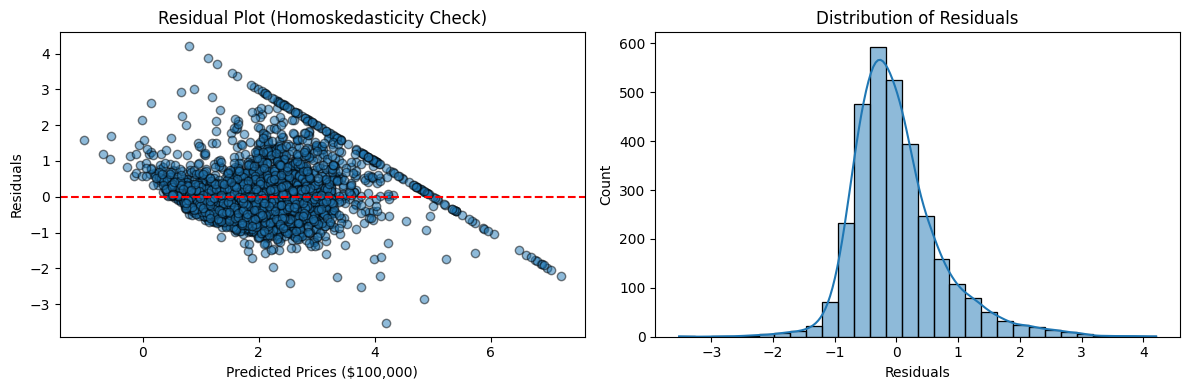

Mean of Residuals: 0.009953 (should be close to 0)


In [22]:
#Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices ($100,000)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoskedasticity Check)")  

plt.subplot(1,2,2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {residuals.mean():.6f} (should be close to 0)")

   index       price       district           city  bed_rooms  bath_rooms  \
0      1  5900000000   Citra Garden  Jakarta Barat          2           4   
1      2  2700000000       Jelambar  Jakarta Barat          4           2   
2      3  2200000000       Jelambar  Jakarta Barat          3           3   
3      4  1900000000       Jelambar  Jakarta Barat          3           2   
4      5  2100000000  Tanjung Duren  Jakarta Barat          4           3   

   carport  land_area  building_area  
0        2      250.0          350.0  
1        0      100.0          225.0  
2        0       60.0          140.0  
3        0       60.0          120.0  
4        0       56.0          108.0  
Dataset shape: (10000, 5)

5 first sample: 
   bed_rooms  bath_rooms  carport  land_area  building_area
0          2           4        2      250.0          350.0
1          4           2        0      100.0          225.0
2          3           3        0       60.0          140.0
3          3       

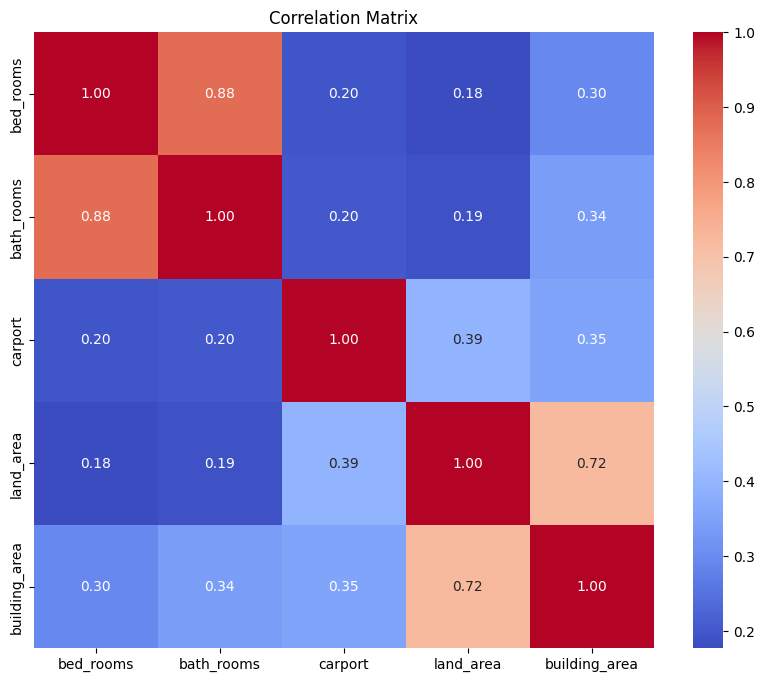


Correlation with target variable:
land_area        0.698065
building_area    0.625742
carport          0.333620
bath_rooms       0.190966
bed_rooms        0.166950
dtype: float64


In [36]:
#Jakarta House Price Prediction
jakarta_housing = pd.read_csv('../data/jakarta_house.csv')
print(jakarta_housing.head())
X_jak = jakarta_housing.drop(columns=['index','price','district','city'])
y_jak = jakarta_housing['price']

# Make categorical to be number
# X = pd.get_dummies(X, columns=['district','city'], drop_first=True)

print("Dataset shape:", X_jak.shape)
print("\n5 first sample: ")
print(X_jak.head())
print(type(y_jak))
print("\n Target (housing price in Rp):",y[:5])

#descriptive statistics
plt.figure(figsize=(10, 8))
sns.heatmap(X_jak.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#Correlation with target variable
corr_with_target = X_jak.corrwith(pd.Series(y_jak))
print("\nCorrelation with target variable:")
print(corr_with_target.sort_values(ascending=False))


Linear Regression Results:

Training Set Evaluation:
Mean Squared Error: 194644444503875813376.0000
Mean Absolute Error: 5002999534.4884
R^2 Score: 0.5272

Validation Set Evaluation:
Mean Squared Error: 337813411497540976640.0000
Mean Absolute Error: 5124007033.6690
R^2 Score: 0.1315

Test Set Evaluation:
Mean Squared Error: 131687713571587358720.0000
Mean Absolute Error: 4748725270.0211
R^2 Score: 0.6425

Coefficients Model:
         Feature   Coefficient
2        carport  2.854819e+08
1     bath_rooms  9.938719e+07
3      land_area  2.391473e+07
4  building_area  2.060606e+07
0      bed_rooms -3.312875e+08


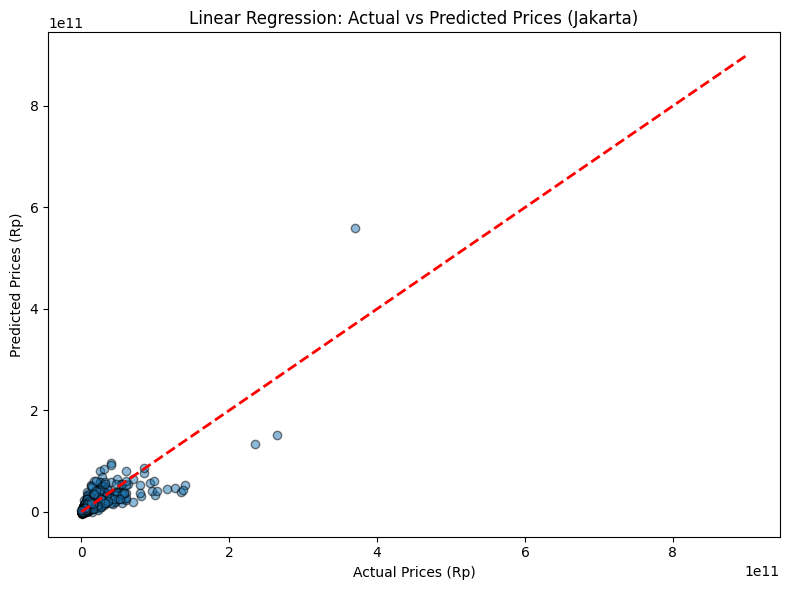

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

feature_names = X_jak.columns
X_jak_imputer = imputer.fit_transform(X_jak)

#Training & Evaluation
# Split data (70% train, 15% validation, 15% test)
X_jak_temp, X_jak_test, y_jak_temp, y_jak_test = train_test_split(X_jak_imputer, y_jak, test_size=0.15, random_state=42)
X_jak_train, X_jak_val, y_jak_train, y_jak_val = train_test_split(X_jak_temp, y_jak_temp, test_size=0.1765, random_state=42) # 0.1765 * 0.85 ≈ 0.15

# Train model
lr_jak_model = LinearRegression()
lr_jak_model.fit(X_jak_train, y_jak_train)

#Prediction
y_jak_train_pred = lr_jak_model.predict(X_jak_train)
y_jak_val_pred = lr_jak_model.predict(X_jak_val)
y_jak_test_pred = lr_jak_model.predict(X_jak_test)


# Evaluation
def evaluate_regression(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    return mse, mae, r2

print("Linear Regression Results:")
evaluate_regression(y_jak_train, y_jak_train_pred, "Training Set")
evaluate_regression(y_jak_val, y_jak_val_pred, "Validation Set")
evaluate_regression(y_jak_test, y_jak_test_pred, "Test Set")

# Coeficients Analysis
coef_jak_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_jak_model.coef_
})

print("\nCoefficients Model:")
print(coef_jak_df.sort_values('Coefficient', ascending=False))

# Visualization of Predictions vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_jak_test, y_jak_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y_jak.min(), y_jak.max()], [y_jak.min(), y_jak.max()], 'r--', lw=2) # Line for perfect predictions
plt.xlabel("Actual Prices (Rp)")
plt.ylabel("Predicted Prices (Rp)")
plt.title("Linear Regression: Actual vs Predicted Prices (Jakarta)")
plt.tight_layout()
plt.show()




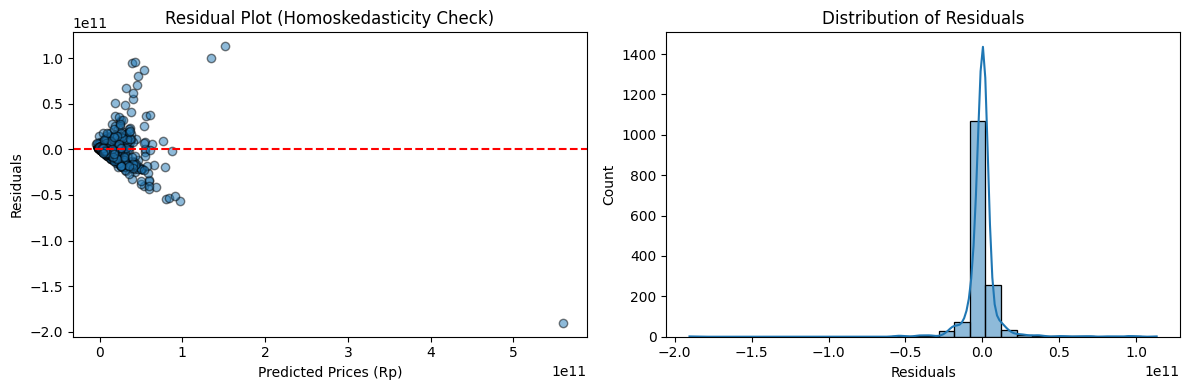

Mean of Residuals: -113754431.719643 (should be close to 0)


In [ ]:
#Residual plot
residuals = y_jak_test - y_jak_test_pred

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_jak_test_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices (Rp)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoskedasticity Check)")


plt.subplot(1,2,2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {residuals.mean():.6f} (should be close to 0)")


Polynomial Regression Results:

Training Set Evaluation:
Mean Squared Error: 151536857433419546624.0000
Mean Absolute Error: 4691981344.6178
R^2 Score: 0.6319

Validation Set Evaluation:
Mean Squared Error: 5091066704967744094208.0000
Mean Absolute Error: 6824825798.1476
R^2 Score: -12.0890

Test Set Evaluation:
Mean Squared Error: 226247475157500166144.0000
Mean Absolute Error: 4650799879.0484
R^2 Score: 0.3858

Coefficients Model:
                     Feature   Coefficient
11        bath_rooms carport  2.508663e+07
10              bath_rooms^2  2.442043e+07
5                bed_rooms^2  2.438508e+07
4              building_area  1.839109e+07
3                  land_area  1.598934e+07
8        bed_rooms land_area  4.310744e+06
13  bath_rooms building_area  2.745951e+06
16     carport building_area  1.526259e+06
1                 bath_rooms  3.827017e+05
15         carport land_area  2.593585e+05
18   land_area building_area  1.931381e+04
17               land_area^2 -5.273132e+03
19  

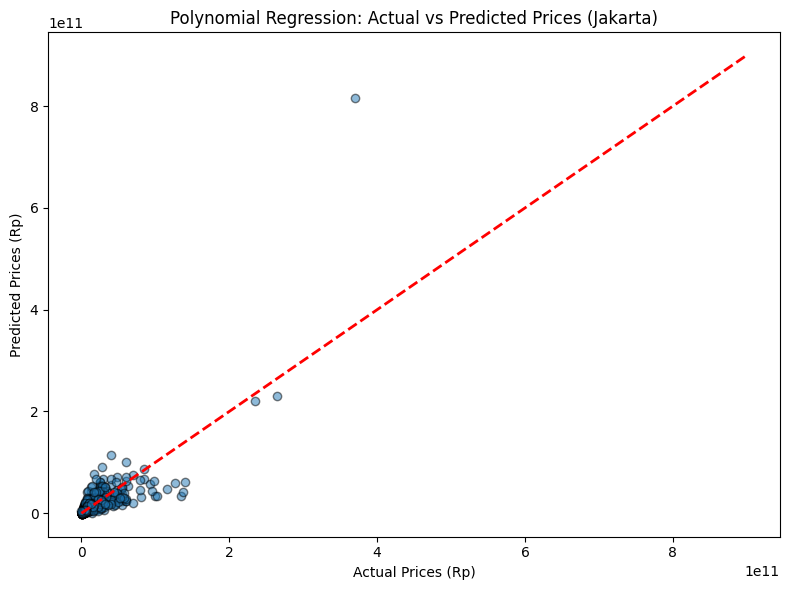

In [44]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_jak_train_poly = poly.fit_transform(X_jak_train)
X_jak_val_poly = poly.transform(X_jak_val)
X_jak_test_poly = poly.transform(X_jak_test)

# Train model
lr_jak_model_poly = LinearRegression()
lr_jak_model_poly.fit(X_jak_train_poly, y_jak_train)

#Prediction
y_jak_train_pred = lr_jak_model_poly.predict(X_jak_train_poly)
y_jak_val_pred = lr_jak_model_poly.predict(X_jak_val_poly)
y_jak_test_pred = lr_jak_model_poly.predict(X_jak_test_poly)

feature_names_poly = poly.get_feature_names_out(
    X_jak.columns
)

# Evaluation
def evaluate_regression(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    return mse, mae, r2

print("Polynomial Regression Results:")
evaluate_regression(y_jak_train, y_jak_train_pred, "Training Set")
evaluate_regression(y_jak_val, y_jak_val_pred, "Validation Set")
evaluate_regression(y_jak_test, y_jak_test_pred, "Test Set")

# Coeficients Analysis
coef_jak_df = pd.DataFrame({
    'Feature': feature_names_poly,
    'Coefficient': lr_jak_model_poly.coef_
})

print("\nCoefficients Model:")
print(coef_jak_df.sort_values('Coefficient', ascending=False))

# Visualization of Predictions vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_jak_test, y_jak_test_pred, alpha=0.5, edgecolors='k')
plt.plot([y_jak.min(), y_jak.max()], [y_jak.min(), y_jak.max()], 'r--', lw=2) # Line for perfect predictions
plt.xlabel("Actual Prices (Rp)")
plt.ylabel("Predicted Prices (Rp)")
plt.title("Polynomial Regression: Actual vs Predicted Prices (Jakarta)")
plt.tight_layout()
plt.show()

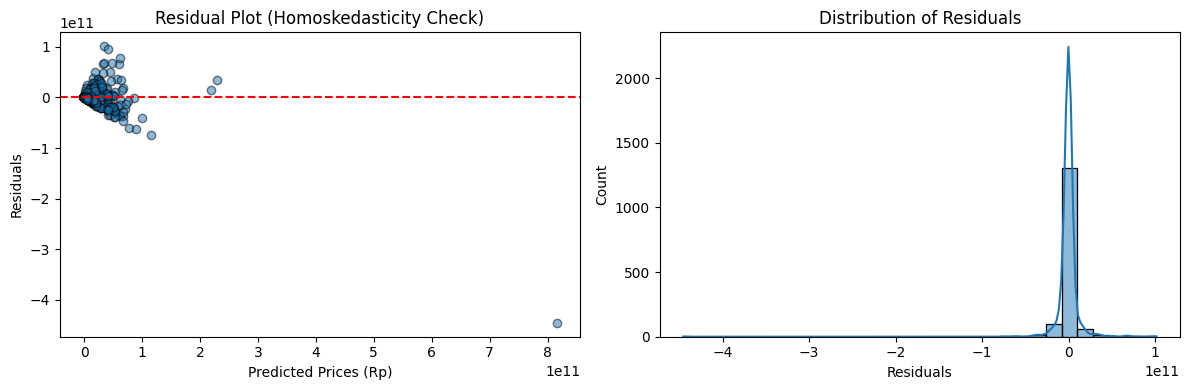

Mean of Residuals: -490634573.176411 (should be close to 0)


In [45]:
#Residual plot
residuals = y_jak_test - y_jak_test_pred

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_jak_test_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices (Rp)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoskedasticity Check)")


plt.subplot(1,2,2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {residuals.mean():.6f} (should be close to 0)")


count    1.000000e+04
mean     1.004029e+10
std      2.004519e+10
min      1.850000e+06
25%      2.500000e+09
50%      4.500000e+09
75%      9.800000e+09
max      9.000000e+11
Name: price, dtype: float64


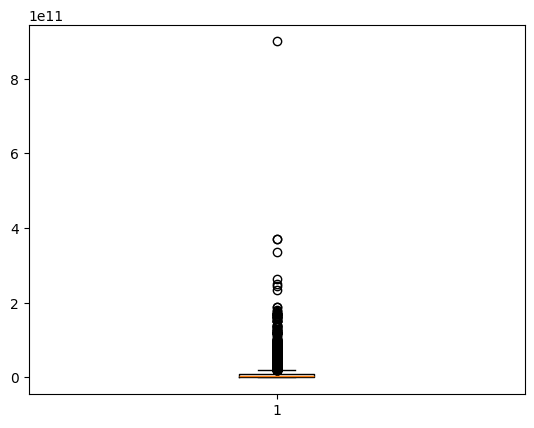

In [47]:
print(y_jak.describe())
plt.boxplot(y_jak)
plt.show()

In [49]:
print(
    y_jak.sort_values().head(20)
)
print(
    y_jak.sort_values().tail(20)
)

3744      1850000
3295      2200000
3291      2300000
3289      3800000
3290      4900000
3298      6850000
3294      7100000
3293     12500000
1013     15000000
1012     22000000
3297     22000000
3292     28000000
3296     53900000
4956    116000000
5954    185000000
684     185000000
957     203000000
1325    230000000
955     258000000
958     281000000
Name: price, dtype: int64
8230    170000000000
2462    170000000000
6096    170000000000
1235    170000000000
8710    170000000000
6742    170000000000
1810    172000000000
4669    175000000000
9259    179000000000
1973    180000000000
4449    190000000000
2552    190000000000
735     235000000000
3592    245000000000
6671    250000000000
6289    265000000000
4435    337000000000
5416    370000000000
577     370000000000
837     900000000000
Name: price, dtype: int64
